In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from pybaseball import statcast, statcast_pitcher, playerid_lookup, playerid_reverse_lookup

pd.set_option('display.max_columns', None)


In [2]:
data = pd.read_csv('pitcher_data.csv')
data['game_date'] = pd.to_datetime(data['game_date'])
data['year'] = data['game_date'].dt.year

detData = pd.read_csv('pitcher_data_detailed.csv')
detData['game_date'] = pd.to_datetime(detData['game_date'])
detData['year'] = detData['game_date'].dt.year

ids = data['pitcher'].unique().tolist()
lookup = playerid_reverse_lookup(ids)
lookup

Gathering player lookup table. This may take a moment.


,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,kershaw,clayton,477132,kersc001,kershcl01,2036,2008.0,2025.0
1,verlander,justin,434378,verlj001,verlaju01,8700,2005.0,2025.0
2,burnes,corbin,669203,burnc002,burneco01,19361,2018.0,2025.0
3,darvish,yu,506433,darvy001,darviyu01,13074,2012.0,2025.0
4,scherzer,max,453286,schem001,scherma01,3137,2008.0,2025.0
5,gray,sonny,543243,grays001,grayso01,12768,2013.0,2025.0
6,sale,chris,519242,salec001,salech01,10603,2010.0,2025.0
7,cole,gerrit,543037,coleg001,colege01,13125,2013.0,2024.0
8,chapman,aroldis,547973,chapa001,chapmar01,10233,2010.0,2025.0
9,lynn,lance,458681,lynnl001,lynnla01,2520,2011.0,2024.0


In [3]:
lookup['pitcher_name'] = lookup['name_first'] + ' ' + lookup['name_last']
data['pitcher_name'] = data['pitcher'].map(lookup.set_index('key_mlbam')['pitcher_name'])

In [4]:
data.head()

,game_date,player_name,pitcher,pitch_type,pitch_name,release_speed,release_spin_rate,pfx_x,pfx_z,release_pos_x,release_pos_z,release_extension,spin_axis,year,pitcher_name
0,2020-07-24,"Verlander, Justin",434378,FF,4-Seam Fastball,95.3,2523.0,-1.02,1.68,-1.71,6.80,6.1,210.0,2020,justin verlander
1,2020-07-24,"Verlander, Justin",434378,FF,4-Seam Fastball,93.4,2444.0,-0.96,1.72,-1.69,6.74,6.4,210.0,2020,justin verlander
2,2020-07-24,"Verlander, Justin",434378,FF,4-Seam Fastball,93.3,2466.0,-0.98,1.64,-1.78,6.85,6.2,210.0,2020,justin verlander
3,2020-07-24,"Verlander, Justin",434378,SL,Slider,85.7,2404.0,0.53,0.64,-1.94,6.73,6.1,184.0,2020,justin verlander
4,2020-07-24,"Verlander, Justin",434378,SL,Slider,85.0,2491.0,0.61,0.86,-1.85,6.81,6.1,195.0,2020,justin verlander


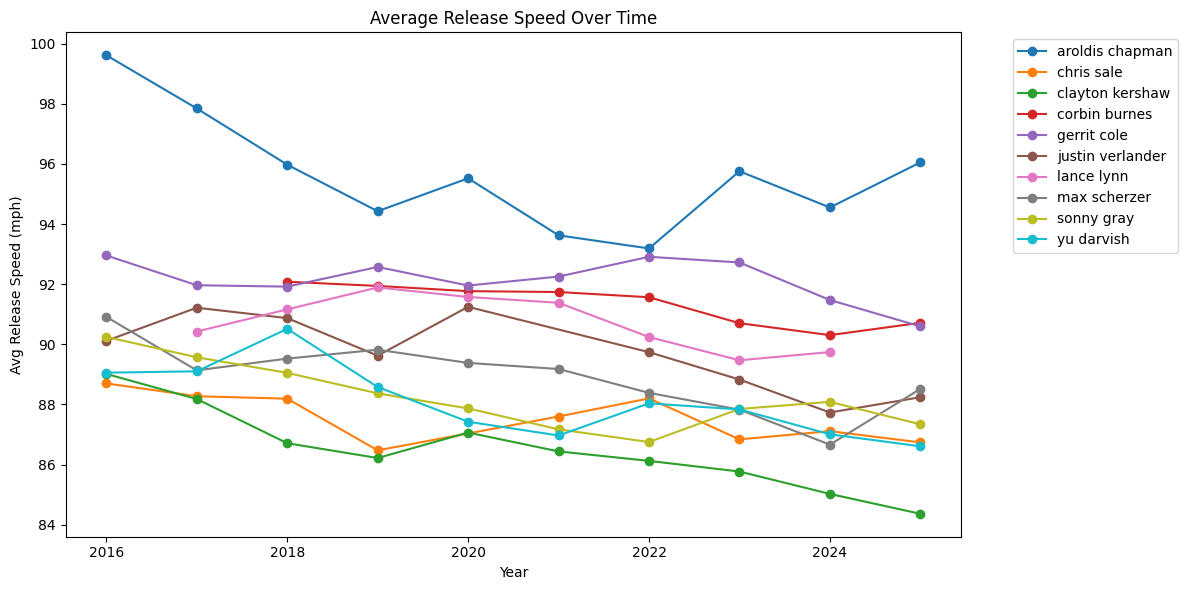

In [5]:
yearly_avg = data.groupby(['pitcher_name', 'year'])['release_speed'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
for name, group in yearly_avg.groupby('pitcher_name'):
    ax.plot(group['year'], group['release_speed'], marker='o', label=name)
ax.set_title('Average Release Speed Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Release Speed (mph)')
ax.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [6]:
pitch_types_per_year = data.groupby(['pitcher_name', 'year'])['pitch_type'].nunique().reset_index()
pitch_types_per_year.columns = ['pitcher_name', 'year', 'num_pitch_types']
pitch_types_per_year

,pitcher_name,year,num_pitch_types
0,aroldis chapman,2016,3
1,aroldis chapman,2017,4
2,aroldis chapman,2018,4
3,aroldis chapman,2019,4
4,aroldis chapman,2020,4
...,...,...,...
89,yu darvish,2021,9
90,yu darvish,2022,9
91,yu darvish,2023,10
92,yu darvish,2024,9


In [7]:
avg_pitch_types = pitch_types_per_year.groupby('pitcher_name')['num_pitch_types'].mean().reset_index()
avg_pitch_types

,pitcher_name,num_pitch_types
0,aroldis chapman,3.900000
1,chris sale,3.888889
2,clayton kershaw,5.400000
3,corbin burnes,6.125000
4,gerrit cole,5.600000
5,justin verlander,5.000000
6,lance lynn,5.625000
7,max scherzer,5.100000
8,sonny gray,7.500000
9,yu darvish,9.500000


In [8]:
# chart of pitch types and pitch names
pitch_type_counts = data.groupby(['pitch_name', 'pitch_type']).size().reset_index(name='count')
fig = px.bar(pitch_type_counts, x='pitch_type', y='count', color='pitch_name', barmode='group', 
             title='Count of Each Pitch Name Grouped by Pitch Type')
fig.show()
display(pitch_type_counts)

,pitch_name,pitch_type,count
0,4-Seam Fastball,FF,82188
1,Changeup,CH,14199
2,Curveball,CU,20128
3,Cutter,FC,17005
4,Eephus,EP,1
5,Intentional Ball,IN,19
6,Knuckle Curve,KC,4531
7,Other,FA,1
8,Pitch Out,PO,11
9,Sinker,SI,20252


In [9]:
detData.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,pitcher,events,description,spin_dir,zone,des,p_throws,type,game_year,release_spin_rate,release_extension,release_pos_y,babip_value,iso_value,launch_speed,pitch_number,pitch_name,spin_axis,hyper_speed,age_pit,n_thruorder_pitcher,pitcher_days_since_prev_game,arm_angle,year
0,NaN,2020-03-10,NaN,NaN,NaN,"Gilbert, Logan",669302,strikeout,called_strike,NaN,NaN,Matt Thaiss called out on strikes.,R,S,2020,NaN,NaN,NaN,0.0,0.0,NaN,3,NaN,NaN,NaN,23,1,NaN,NaN,2020
1,NaN,2020-03-10,NaN,NaN,NaN,"Gilbert, Logan",669302,NaN,foul,NaN,NaN,Foul,R,S,2020,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,23,1,NaN,NaN,2020
2,NaN,2020-03-10,NaN,NaN,NaN,"Gilbert, Logan",669302,NaN,swinging_strike,NaN,NaN,Swinging Strike,R,S,2020,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,23,1,NaN,NaN,2020
3,NaN,2020-03-10,NaN,NaN,NaN,"Gilbert, Logan",669302,field_out,hit_into_play,NaN,NaN,Michael Hermosillo flies out to center fielder...,R,X,2020,NaN,NaN,NaN,0.0,0.0,NaN,1,NaN,NaN,NaN,23,1,NaN,NaN,2020
4,NaN,2020-03-10,NaN,NaN,NaN,"Gilbert, Logan",669302,strikeout,swinging_strike,NaN,NaN,Shohei Ohtani strikes out swinging.,R,S,2020,NaN,NaN,NaN,0.0,0.0,NaN,3,NaN,NaN,NaN,23,1,NaN,NaN,2020


In [10]:
display(detData.isnull().sum().sort_values(ascending=False)/len(detData))
keep_cols = [col for col in detData.columns[detData.isnull().mean() < 0.1].tolist() if col not in ['des', 'description']]

spin_dir                        1.000000
events                          0.736553
babip_value                     0.736553
iso_value                       0.736553
launch_speed                    0.700886
hyper_speed                     0.699331
arm_angle                       0.383676
pitcher_days_since_prev_game    0.092071
spin_axis                       0.080529
release_spin_rate               0.045763
release_extension               0.036527
zone                            0.033323
pitch_name                      0.033202
pitch_type                      0.033202
release_pos_x                   0.033027
release_pos_z                   0.033027
release_pos_y                   0.033027
release_speed                   0.032984
pitcher                         0.000000
player_name                     0.000000
game_date                       0.000000
description                     0.000000
type                            0.000000
p_throws                        0.000000
des             

In [ ]:
detData2 = detData[keep_cols].copy()
detData2.head()

pitcher_days_since_prev_game    0.092071
spin_axis                       0.080529
release_spin_rate               0.045763
release_extension               0.036527
zone                            0.033323
pitch_type                      0.033202
pitch_name                      0.033202
release_pos_x                   0.033027
release_pos_z                   0.033027
release_pos_y                   0.033027
release_speed                   0.032984
game_date                       0.000000
player_name                     0.000000
type                            0.000000
game_year                       0.000000
pitcher                         0.000000
p_throws                        0.000000
pitch_number                    0.000000
age_pit                         0.000000
n_thruorder_pitcher             0.000000
year                            0.000000
dtype: float64

In [14]:
print(detData2.isna().any(axis=1).sum() / len(detData2))
display(detData2.sort_values(['player_name', 'game_date', 'pitch_number']).head(20))
detData2.dropna().to_csv('pitcher_data_detailed_cleaned.csv', index=False)

0.1444934489559682


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,pitcher,zone,p_throws,type,game_year,release_spin_rate,release_extension,release_pos_y,pitch_number,pitch_name,spin_axis,age_pit,n_thruorder_pitcher,pitcher_days_since_prev_game,year
439979,FF,2017-02-26,91.0,-2.78,6.00,"Almonte, Yency",622075,8.0,R,X,2017,2654.0,6.6,53.95,1,4-Seam Fastball,171.0,23,1,NaN,2017
439985,FF,2017-02-26,91.7,-3.02,5.93,"Almonte, Yency",622075,5.0,R,S,2017,2002.0,6.8,53.66,1,4-Seam Fastball,217.0,23,1,NaN,2017
439988,FF,2017-02-26,96.6,-2.86,6.04,"Almonte, Yency",622075,11.0,R,B,2017,2317.0,6.9,53.61,1,4-Seam Fastball,200.0,23,1,NaN,2017
439991,SL,2017-02-26,87.3,-2.93,6.08,"Almonte, Yency",622075,2.0,R,S,2017,2481.0,6.5,53.97,1,Slider,181.0,23,1,NaN,2017
439996,FF,2017-02-26,97.1,-2.81,5.95,"Almonte, Yency",622075,1.0,R,S,2017,2357.0,7.1,53.41,1,4-Seam Fastball,232.0,23,1,NaN,2017
439999,FF,2017-02-26,96.4,-2.86,5.89,"Almonte, Yency",622075,11.0,R,B,2017,2257.0,7.2,53.32,1,4-Seam Fastball,234.0,23,1,NaN,2017
440005,FF,2017-02-26,91.6,-3.15,5.74,"Almonte, Yency",622075,14.0,R,B,2017,2017.0,6.9,53.59,1,4-Seam Fastball,218.0,23,1,NaN,2017
440012,FF,2017-02-26,96.3,-3.21,5.89,"Almonte, Yency",622075,6.0,R,S,2017,2221.0,6.8,53.69,1,4-Seam Fastball,206.0,23,1,NaN,2017
439984,FF,2017-02-26,97.1,-2.95,5.96,"Almonte, Yency",622075,13.0,R,B,2017,2384.0,6.6,53.94,2,4-Seam Fastball,222.0,23,1,NaN,2017
439987,FF,2017-02-26,96.7,-2.68,6.15,"Almonte, Yency",622075,12.0,R,S,2017,2279.0,6.9,53.64,2,4-Seam Fastball,196.0,23,1,NaN,2017
